In [1]:
import numpy as np
import math
import matplotlib.pylab as plt
import random as rn
import time
from scipy.spatial import ConvexHull
from matplotlib.patches import Rectangle
from matplotlib.path import Path
from mpl_toolkits.mplot3d import Axes3D
import shapely.geometry as geometry
import shapely.ops as so
from Dynamic import DynamicMap
from Camera import Camera
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry.polygon import Polygon
from scipy.spatial import KDTree
import json, os
from shapely.ops import unary_union
from shapely.prepared import prep
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
from mpl_toolkits.mplot3d import Axes3D


In [2]:
# Import JSON for parameters
file_path1 = os.path.join("json", "operation_map.json")
file_path2 = os.path.join("json", "defender_info.json")
file_path3 = os.path.join("json", "stp_rrt_setup.json")
# file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
# file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
# file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

with open(file_path1, "r") as f:
    aoe_param_dict = json.load(f)

with open(file_path2, "r") as f:
    cam_param_dict = json.load(f)

with open(file_path3, "r") as f:
    stp_rrt_setup = json.load(f)

In [3]:
# ---------- 1) Precompute acceleration structure (static union, pan-rate, fov) ----------
def setup_collision_accel(map_in, cam_dict):
    """
    Build fast data for collision checks.

    Returns:
      accel = {
        'static_union_prep': PreparedGeometry of unified static obstacles (or None),
        'max_pan_rate': max |pan speed| [rad/s] across cameras (float),
        'fov_half': FOV half-angle [rad] (float),
      }
    """
    st = map_in["st"]
    n_static = int(st["n"])
    static_polys = [Polygon(st[str(i)]) for i in range(n_static)]
    static_union = unary_union(static_polys) if n_static > 0 else None
    static_union_prep = prep(static_union) if static_union is not None else None

    spec = cam_dict["spec"]
    pans = np.array(spec.get("panspeed", []), dtype=float)
    max_pan_rate = float(np.max(np.abs(pans))) if pans.size else 0.0
    fov_half = float(spec["fov"][0])

    return {
        "static_union_prep": static_union_prep,
        "max_pan_rate": max_pan_rate,
        "fov_half": fov_half,
    }

# ---------- 2) Robust extractor for FOV polygon from dmap.gen_cam ----------
def _extract_fov_poly(gen_cam_output, idx):
    """
    Make very few assumptions about DynamicMap.gen_cam return type.
    Accepts:
      - {'FOV_Poly': Polygon}
      - {str(idx): {'FOV_Poly': Polygon}}
      - Polygon directly
    Returns Polygon or None.
    """
    out = gen_cam_output
    if hasattr(out, 'geom_type'):  # Shapely geometry directly
        return out
    if isinstance(out, dict):
        if 'FOV_Poly' in out and hasattr(out['FOV_Poly'], 'geom_type'):
            return out['FOV_Poly']
        key = str(idx)
        if key in out and isinstance(out[key], dict) and 'FOV_Poly' in out[key]:
            poly = out[key]['FOV_Poly']
            if hasattr(poly, 'geom_type'):
                return poly
    return None


In [4]:
# Operation Map Visualization
def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """
    Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t.
    Angles are radians; panspeed is rad per unit time.
    """
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

def visualize_map_at_time(map_in, cam_dict, t: float, sensor_alpha: float = 0.5, ax=None):
    """
    Visualize the operation map at time t using your schema.

    Args:
        map_in: dict with 'st': {'size': [xmin,xmax,ymin,ymax], 'n': int, '0': poly0, ...}
        cam_dict: dict with 'n', 'x', 'y', and 'spec' fields:
            - spec['init_angle'] : list of radians
            - spec['bound']      : array-like shape (n, 2) = [ [ +max, -max ], ... ]
            - spec['fov']        : [ half_angle_rad, range ]
            - spec['cam_time']   : [ cam_period, cam_increment ]  (not required here)
            - spec['panspeed']   : list of rad/time
        t: time (same units as your panspeed / cam_time increment)
        sensor_alpha: alpha for the green FOV wedges
        ax: optional matplotlib Axes; if None, a new figure/axes is created

    Returns:
        fig, ax
    """
    # ---- Static map bounds & buildings ----
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)   # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size

    buildings = []
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        buildings.append(poly)

    # ---- Cameras & spec ----
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)          # radians
    bound_arr = np.array(spec["bound"], dtype=float)                 # (n,2) = [+max, -max]
    fov_half = float(spec["fov"][0])                                 # radians
    fov_range = float(spec["fov"][1])                                # map units
    panspeeds = np.array(spec["panspeed"], dtype=float)              # rad/time

    # Compute facing angles at time t with bounce pan
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    # ---- Plot ----
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")

    # FOV wedges: green with alpha
    for i in range(len(cx)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx[i], cy[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor="green",
            edgecolor=None,
            alpha=float(sensor_alpha),
            zorder=2
        )
        ax.add_patch(wedge)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Operation Map @ t = {t:.2f}")
    return fig, ax


In [5]:
# Data ogranization for STP-RRT*

# Position
map_size = [aoe_param_dict['st']['size'][1], aoe_param_dict['st']['size'][3]]
x0 = stp_rrt_setup['x0']
xf = stp_rrt_setup['xf']

# Static / Dynamic obstacles
n_static = aoe_param_dict['st']['n']
n_dynamic = aoe_param_dict['ncam']

# static_obstacle_position: [anchor point, width, height]
static_obstacle_pos = []
for nb in range(n_static):
    static_obstacle_pos.append(aoe_param_dict['st'][str(nb)])

dynamic_obstacle_pos = []
for ns in range(n_dynamic):
    dynamic_obstacle_pos.append([cam_param_dict['x'][ns], cam_param_dict['y'][ns]])
prox = [2.5, 2.5] # [x, t]

# General RRT Settings
vmax = stp_rrt_setup['vmax']/2
max_time = 5

# Sensor Parameterization
tilt_limit = cam_param_dict['spec']['bound']
fov_ang = cam_param_dict['spec']['fov'][0]
fov_rng = cam_param_dict['spec']['fov'][1]
panSpeed = cam_param_dict['spec']['panspeed']

# Test case
# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 0.5
t = [200, .25, 500]

# Map
map_in = {}
# Static Map
map_in['st'] = {}
map_in['st']['size'] = np.array([0, map_size[0], 0, map_size[1]])
map_in['st']['n'] = n_static
for nb in range(n_static):
    map_in['st'][str(nb)] = aoe_param_dict['st'][str(nb)]

# Dynamic Map
# This is a continuous function generates camera FOV coverages
# Input is map_in, and time input t_in
map_in['n'] = t[0]

# Single camera example, surveying final location xfins
# Camera Position
cam_x = cam_param_dict['x']
cam_y = cam_param_dict['y']
cam_dict = {}
cam_dict['n'] = n_dynamic
map_in['ncam'] = n_dynamic
cam_dict['x'] = cam_x
cam_dict['y'] = cam_y

# Camera Spec
cam_period = t[0]
cam_increment = t[1]
cam_dict['spec'] = {}
cam_dict['spec']['init_angle'] = cam_param_dict['spec']['init_angle']
cam_dict['spec']['bound'] = tilt_limit
cam_dict['spec']['fov'] = [fov_ang, fov_rng]
cam_dict['spec']['cam_time'] = [cam_period, cam_increment]
cam_dict['spec']['panspeed'] = panSpeed

# Test dynamic map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap
accel = setup_collision_accel(map_in, cam_dict)

direc_param_lambda = 0.5
direc_param_beta = 0.4

In [6]:
# TODO
# Add static omni-directional sensor at given location
dt1_denum = 20
omni_sensor_pos_x = [25, 25]
omni_sensor_pos_y = [15, 35]
omni_sensor_range = [30, 30]
num_omni = len(omni_sensor_pos_x)
# omni_sensor_pos_x = [(map_in['st']['size'][1]-map_in['st']['size'][0])/2]
# omni_sensor_pos_y = [(map_in['st']['size'][3]-map_in['st']['size'][2])/2]
# omni_sensor_range = [20]
# omni_sensor_range = [(map_in['st']['size'][1]-map_in['st']['size'][0])]
# omni_dt1 = float(omni_sensor_range)/100
# omni_dt2 = float(omni_sensor_range)        # your omni sensor range cutoff
omni_param_lambda = 0.5
omni_param_beta = 0.25

STP-RRT*

In [7]:
def distance(a, b):
    return np.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)

In [8]:
def random_sample(tf, nn, k):
    trand = rn.uniform(0, tf)
    sample_goal = rn.uniform(0, 1) < 0.1
    # Find a random point in a domain
    if sample_goal:
        # IF not, sample goal
        if np.mod(k, nn) == 0:
            xrand = xf[0]
            yrand = xf[1]
            trand = tf
        else:
            xrand = x0[0]
            yrand = x0[1]
            trand = x0[2]
    elif not sample_goal:
        # Construct Points for Convex Hull
        point1 = [x0[0], x0[2]]
        point2 = [0, x0[0]/vmax]
        point3 = [map_size[0], (map_size[0]-x0[0])/vmax]
        point4 = [0, tf-xf[0]/vmax]
        point5 = [map_size[0], tf+xf[0]/vmax-map_size[0]/vmax]
        point6 = [xf[0], tf]
        pos = [point1, point2, point3, point4, point5, point6]

        # Convex hull
        hull = ConvexHull( pos )
        # Bounding box
        bbox = [hull.min_bound, hull.max_bound]
        #Hull path
        hull_path = Path(hull.points[hull.vertices])
        # Draw n
        rand_points = np.empty((1, 2))
        for i in range(1):
            rand_points[i] = np.array([np.random.uniform(bbox[0][0], bbox[1][0]), np.random.uniform(bbox[0][1], bbox[1][1])])

            while hull_path.contains_point(rand_points[i]) == False:
                rand_points[i] = np.array([np.random.uniform(bbox[0][0], bbox[1][0]), np.random.uniform(bbox[0][1], bbox[1][1])])
        xrand = rand_points[0][0]
        trand = rand_points[0][1]
        yrand = rn.uniform(np.min([0, x0[0]/vmax]), np.min([vmax*(trand+x0[0]/vmax), map_size[1]]))

    return [xrand, yrand, trand]

In [9]:
def reachable(q0, q1, forward=True):
    dx = np.abs(q1[0]-q0[0])
    dy = np.abs(q1[1]-q0[1])
    dd = np.sqrt(dx**2 + dy**2)
    dt = q1[2]-q0[2]

    if dd == 0:
        return True
    else:
        if forward and dt > 0 and dd/dt <= vmax:
            return True
        elif not forward and dt < 0 and dd/dt <= vmax:
            return True
        return False

In [10]:
def find_neighbor(qrand, V, n, k, query_max=10, closest=True):
    # Find Neighbor
    if np.mod(k,n) == 0:
        forward = True
    else:
        forward = False

    kdtree=KDTree(V)
    dist,points=kdtree.query(qrand,query_max)
    points_list = [i for n, i in enumerate(points) if i not in points[:n]]

    if closest:
        if len(V) < query_max:
            for ii in range(len(V)):
                pointToCheck = V[points_list[ii]]
                if reachable(pointToCheck, qrand, forward):
                    return pointToCheck
            return None
        else:
            for ii in range(len(points_list)):
                pointToCheck = V[points_list[ii]]
                if reachable(pointToCheck, qrand, forward):
                    return pointToCheck
            return None
    else:
        return points

In [11]:
def extend(q0, q1, max_time):
    dx = q1[0]-q0[0]
    dy = q1[1]-q0[1]
    dt = q1[2]-q0[2]
    max_distance = max_time

    if np.abs(dx)<=max_distance and \
       np.abs(dy)<=max_distance and \
       np.abs(dt)<=max_time:
        qnew = q1
    else:
        norm = np.sqrt(dx**2+dy**2+dt**2)
        dxnorm = dx/norm*vmax
        dynorm = dy/norm*vmax
        dtnorm = dt/norm*vmax
        qnew = [q0[0]+dxnorm, q0[1]+dynorm, q0[2]+dtnorm]
    return qnew

In [12]:
def _bounce_angle(theta0: float, bound_plus: float, bound_minus: float, panspeed: float, t: float) -> float:
    """
    Bounce-pan angle inside [theta0+bound_minus, theta0+bound_plus] at time t.
    Angles are radians; panspeed is rad per unit time.
    """
    lo = theta0 + float(bound_minus)
    hi = theta0 + float(bound_plus)
    if lo > hi:
        lo, hi = hi, lo
    span = hi - lo
    if span <= 1e-12 or abs(panspeed) <= 1e-12:
        return theta0
    raw = theta0 + panspeed * t
    period = 2.0 * span
    off = (raw - lo) % period
    return (lo + off) if (off <= span) else (hi - (off - span))

In [13]:
def detection_Cost(qa, qs, dt1=0, dt2=fov_rng, param_lambda=direc_param_lambda, param_beta=direc_param_beta):
    """
    Compute detection cost: Elfes's model
    Inputs:
        qa: [x, y, t] attacker position
        qs: [x, y] sensor position
    """
    # Set exponential decay function parameters
    # dt1 = 0
    # dt2 = fov_rng
    # param_lambda = 1
    # param_beta = 1

    dist_def_to_atk = distance(qa, qs)

    if dist_def_to_atk <= dt1:
        detection_cost = 1
    elif dist_def_to_atk > dt1 and dist_def_to_atk < dt2:
        detection_cost = np.exp(-param_lambda*(dist_def_to_atk-dt1)**param_beta)
    else:
        detection_cost = 0

    return detection_cost
    

In [14]:
def validate(q, vehicle_radius=0.5, debug=False):
    """
    Validate the point while doing collision check
    """
    # True:  No collision
    # False: Collision detected
    tGiven = q[2]

    # Generate vehicle with circular collision radius
    vehicle_centre = Point(q[0], q[1])
    vehicle_collision_bound = vehicle_centre.buffer(vehicle_radius)

    checkInMap = []
    # Check for map
    # Check if x coordinate is OK
    if q[0] >= 0 and q[0] <= map_size[0]:
        # Check if y coordinate is OK
        if q[1] >= 0 and q[1] <= map_size[1]:
            checkInMap = True
        else:
            return False
    else:
        return False

    checkStatic = True
    # Check for static
    for i in range(n_static):
        static_polygon = Polygon(map_in['st'][str(i)])
        if static_polygon.intersects(vehicle_collision_bound) is True:
            return False

    # Initialize detection cost
    cumulative_detection_cost = 0

    # Check for omni-directional sensor at fixed position
    for omni_i in range(num_omni):
        if debug:
            print('=============Checking Omni-Sensor '+str(i)+'=============')
        cumulative_detection_cost += detection_Cost(qa=q,
                                                    qs=[omni_sensor_pos_x[i],omni_sensor_pos_y[i]],
                                                    dt1=omni_sensor_range[i]/dt1_denum,
                                                    dt2=omni_sensor_range[i],
                                                    param_lambda=omni_param_lambda,
                                                    param_beta=omni_param_beta)

    checkDynamic = True
    # Check for dynamic    
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    for i in range(cam_dict['n']):
        if debug:
            print('=============Checking Sensor '+str(i)+'=============')
        def fov_sector_polygon(cx, cy, theta_rad, fov_half_rad, rng, n_arc=64):
            # theta_rad: CCW from +x, radians
            c, s = np.cos(theta_rad), np.sin(theta_rad)
            R = np.array([[c, -s],[s,  c]])        # det +1 rotation
            phis = np.linspace(-fov_half_rad, +fov_half_rad, int(n_arc))
            arc_local = np.stack([rng*np.cos(phis), rng*np.sin(phis)], axis=1)  # (n,2)
            arc_world = (R @ arc_local.T).T + np.array([cx, cy])
            pts = np.vstack([[cx, cy], arc_world, [cx, cy]])  # apex → arc → apex
            return Polygon(pts)

        theta = _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], tGiven)  # radians, CCW
        cam_poly = fov_sector_polygon(cx[i], cy[i], theta, fov_half, fov_range)
        if cam_poly.covers(vehicle_collision_bound):
            # checkDynamic = False
            # break
            cumulative_detection_cost += detection_Cost(qa=q, qs=[cx[i], cy[i]])
            if debug:
                print('Cost from Sensor '+str(i)+': '+str(detection_Cost(qa=q, qs=[cx[i], cy[i]])))
        else:
            if debug:
                print('Cost from Sensor '+str(i)+': 0')
        
    # True: Collision-Free
    # False: Collision
    if debug:
        print('===========================================')
        print('Cumulative cost: '+str(cumulative_detection_cost))
    return bool(checkInMap) and bool(checkStatic), cumulative_detection_cost

In [15]:
# # ---------- 3) Point validator (map bounds, static, dynamic at given t) ----------
# def validate_point(q, map_size, map_in, cam_dict, dmap, vehicle_radius=0.5, accel=None):
#     """
#     True => collision-free at (x,y,t), False => collides with map boundary, static obstacle, or any FOV at time t.
#     """
#     x, y, t = float(q[0]), float(q[1]), float(q[2])

#     # Bounds check
#     if not (0.0 <= x <= float(map_size[0]) and 0.0 <= y <= float(map_size[1])):
#         return False

#     # Vehicle footprint
#     vehicle_disc = Point(x, y).buffer(float(vehicle_radius))

#     # Static obstacles (use prepared union if available)
#     if accel is not None and accel.get("static_union_prep", None) is not None:
#         if accel["static_union_prep"].intersects(vehicle_disc):
#             return False
#     else:
#         n_static = int(map_in["st"]["n"])
#         for i in range(n_static):
#             if Polygon(map_in["st"][str(i)]).intersects(vehicle_disc):
#                 return False

#     # Dynamic obstacles (sensor FOV) at time t
#     n_cam = int(cam_dict["n"])
#     for i in range(n_cam):
#         fov_obj = dmap.gen_cam(i, t)
#         fov_poly = _extract_fov_poly(fov_obj, i)
#         if fov_poly is not None and fov_poly.intersects(vehicle_disc):
#             return False

#     return True

def validate_point(q, map_size, map_in, cam_dict, dmap, vehicle_radius=0.5, accel=None, debug=False):
    x, y, t = float(q[0]), float(q[1]), float(q[2])

    # Bounds check
    if not (0 <= x <= float(map_size[0]) and 0 <= y <= float(map_size[1])):
        if debug:
            print('Point is out of map bounds.')
        return False, 0.0
    
    vehicle_disc = Point(x, y).buffer(float(vehicle_radius))

    # Static obstacles
    if accel is not None and accel.get("static_union_prep", None) is not None:
        if accel["static_union_prep"].intersects(vehicle_disc):
            if debug:
                print('Point collides with static obstacle.')
            return False, 0.0
    else:
        n_static = int(map_in["st"]["n"])
        for i in range(n_static):
            if Polygon(map_in["st"][str(i)]).intersects(vehicle_disc):
                if debug:
                    print('Point collides with static obstacle.')
                return False, 0.0
            
    cumulative_detection_cost = 0.0
    n_cam = int(cam_dict["n"])
    for cam_idx in range(n_cam):
        fov_obj = dmap.gen_cam(cam_idx, t)
        fov_poly = _extract_fov_poly(fov_obj, cam_idx)

        if fov_poly is not None:
            if fov_poly.covers(vehicle_disc):
                cx = float(cam_dict["x"][cam_idx])
                cy = float(cam_dict["y"][cam_idx])
                cost = detection_Cost(qa=q, qs=[cx, cy])
                cumulative_detection_cost += cost
                if debug:
                    print(f"[Sensor {cam_idx}] Cost = {cost}")

            else:
                if debug:
                    print(f"[Sensor {cam_idx}] Cost = 0")

    return True, cumulative_detection_cost

# ---------- 4) Edge (segment) validator with adaptive time-space sampling ----------
def collision_free_segment(q1, q2, map_size, map_in, cam_dict, dmap,
                           vehicle_radius=0.5, accel=None,
                           safety_angle_frac=6, min_points=3, max_points=2000):
    """
    Check the whole edge from q1 to q2:
      - Exact static sweep: buffered line vs prepared union (no temporal sampling needed)
      - Dynamic FOV: adaptive sampling in time to avoid aliasing with camera pan

    Parameters
    ----------
    q1, q2 : array-like [x, y, t]
    vehicle_radius : collision radius of attacker (m)
    accel : dict from setup_collision_accel(...)
    safety_angle_frac : integer; per-step yaw limit = fov_half / safety_angle_frac
    min_points : minimum # of samples along the edge (including endpoints)
    max_points : cap on samples
    """
    q1 = np.asarray(q1, dtype=float)
    q2 = np.asarray(q2, dtype=float)
    p1, p2 = q1[:2], q2[:2]
    t1, t2 = float(q1[2]), float(q2[2])

    # --- (A) Exact static sweep (geometry in R^2)
    line = LineString([tuple(p1), tuple(p2)])
    swept = line.buffer(float(vehicle_radius), cap_style=1)  # flat caps are fine

    if accel is not None and accel.get("static_union_prep", None) is not None:
        if accel["static_union_prep"].intersects(swept):
            return False
    else:
        n_static = int(map_in["st"]["n"])
        static_union = unary_union([Polygon(map_in["st"][str(i)]) for i in range(n_static)]) if n_static > 0 else None
        if static_union is not None and static_union.intersects(swept):
            return False

    # --- (B) Adaptive dynamic sweep (geometry in R^2 × time)
    dxy = float(np.linalg.norm(p2 - p1))
    dt  = abs(t2 - t1)

    # Spatial safety: avoid tunneling (points <= vehicle_radius/2 apart)
    ds = max(float(vehicle_radius) * 0.5, 1e-6)
    n_space = int(math.ceil(dxy / ds)) + 1

    # Temporal safety: limit camera yaw change per sample
    max_pan = 0.0
    fov_half = math.pi / 3  # default 60 deg half-angle if missing
    if accel is not None:
        max_pan  = float(accel.get("max_pan_rate", 0.0))
        fov_half = float(accel.get("fov_half", fov_half))
    n_time = 1
    if max_pan > 0.0 and dt > 0.0:
        dtheta_max = fov_half / float(safety_angle_frac)   # per-step pan allowance
        dt_step = dtheta_max / max_pan                     # seconds per step
        n_time = int(math.ceil(dt / max(dt_step, 1e-6))) + 1

    n_samples = int(np.clip(max(min_points, max(n_space, n_time)), min_points, max_points))

    xs = np.linspace(p1[0], p2[0], n_samples)
    ys = np.linspace(p1[1], p2[1], n_samples)
    ts = np.linspace(t1, t2, n_samples)

    for x, y, t in zip(xs, ys, ts):
        if not validate_point([x, y, t], map_size, map_in, cam_dict, dmap, vehicle_radius, accel):
            return False

    return True


In [16]:
def setup_collision_accel(map_in, cam_dict):
    """
    Precompute fast data structures for collision checks.

    Returns a dict 'accel' with:
      - static_union, static_union_prep: unified static geometry (prepared)
      - max_pan_rate: max |panspeed| across all cameras
      - fov_half: camera fov_half_rad
    """
    st = map_in["st"]
    n_static = int(st["n"])
    static_polys = [Polygon(st[str(i)]) for i in range(n_static)]
    static_union = unary_union(static_polys) if n_static > 0 else None
    static_union_prep = prep(static_union) if static_union is not None else None

    spec = cam_dict["spec"]
    pans = np.array(spec["panspeed"], dtype=float) if len(spec["panspeed"]) else np.array([0.0])
    max_pan_rate = float(np.max(np.abs(pans)))
    fov_half = float(spec["fov"][0])

    return {
        "static_union": static_union,
        "static_union_prep": static_union_prep,
        "max_pan_rate": max_pan_rate,
        "fov_half": fov_half,
    }

In [17]:
def check_route(q1, q2, vehicle_radius=vehicle['radius'], accel=setup_collision_accel(map_in, cam_dict), safety_angle_frac=6,min_points=3, max_points=2000):
    """
    Adaptive route check that is:
      - exact for static collisions (buffered-line vs union polygon)
      - sampled for dynamic FOV using your validate(q)

    Inputs:
      q1, q2: [x, y, t]
      validate: your existing function validate(q, vehicle_radius=...)
      vehicle_radius: float
      accel: result of setup_collision_accel(map_in, cam_dict)
    """
    q1 = np.asarray(q1, dtype=float)
    q2 = np.asarray(q2, dtype=float)

    # 1) EXACT STATIC SWEEP (no sampling):
    # Minkowski sum of path segment with vehicle disc via a buffered LineString.
    if accel["static_union"] is not None:
        sweep = LineString([(q1[0], q1[1]), (q2[0], q2[1])]).buffer(
            vehicle_radius, cap_style=2  # flat caps; use 1 for round if you want extra conservatism
        )
        if accel["static_union_prep"].intersects(sweep):
            return False

    # 2) ADAPTIVE TIME–SPACE SAMPLING for dynamic FOV (and bounds)
    dxy = float(np.linalg.norm(q2[:2] - q1[:2]))
    dt  = float(abs(q2[2] - q1[2]))

    # Spatial safety: ensure points are <= vehicle_radius/2 apart to avoid tunneling
    ds = max(vehicle_radius * 0.5, 1e-6)
    n_space = int(np.ceil(dxy / ds)) + 1

    # Temporal safety: limit camera yaw change per step
    max_pan = float(accel["max_pan_rate"])
    fov_half = float(accel["fov_half"])
    if max_pan > 0.0 and dt > 0.0:
        dtheta_max = fov_half / float(safety_angle_frac)
        # per-step Δt such that |Δθ| <= dtheta_max
        step_dt = max(dtheta_max / max_pan, 1e-9)
        n_time = int(np.ceil(dt / step_dt)) + 1
    else:
        n_time = 2  # endpoints

    n = int(min(max(max(n_space, n_time), int(min_points)), int(max_points)))

    # Vectorized interpolation + early exit loop (validate may not be vectorized)
    alphas = np.linspace(0.0, 1.0, n)
    qpath = q1[None, :] + (q2 - q1)[None, :] * alphas[:, None]
    for i in range(n):
        if not validate_point(qpath[i], map_size, map_in, cam_dict, dmap,
                  vehicle_radius=vehicle['radius'], accel=accel):
        # if not validate(qpath[i], vehicle_radius=vehicle_radius):
            return False

    return True

In [18]:
def find_path(qfin, E, forward=True, tf=None):
    path = []
    path.append(qfin)
    currentNode = qfin
    iter = 0
    while 1:
        for ei in range(len(E)):
            e = E[ei][1]
            
            if currentNode[0]==e[0] and currentNode[1]==e[1] and currentNode[2]==e[2]:
                currentNode = E[ei][0]
                path.append(currentNode)
                break
        iter += 1
        if forward:
            if currentNode[0]==x0[0] and currentNode[1]==x0[1] and currentNode[2]==x0[2]:
                return path
        else:
            if currentNode[0]==xf[0] and currentNode[1]==xf[1] and currentNode[2]==tf:
                return path

In [19]:
def find_neighbors_proximity(prox, q, V):
    output = []
    for v in V:
        if 0 <= q[0]-v[0] <= prox and \
            0 <= q[1]-v[1] <= prox:
            output.append(v)
    return output

In [20]:
"""Parallel RRT in 2D Space-Time"""
def stp_rrtstar(nPartition, compTimeLimit, tf0, tfn, debug = False, view_iter=False):
    RRTP_total_time = []
    RRTP_total_distance = []

    # Enforcement of Computation Time Out
    start = time.monotonic()
    deadline = start + float(compTimeLimit)
    def time_up():
        return time.monotonic() >= deadline

    k = 0
    # Vertex
    V_RRTCa = []
    # Add detection cost for x0
    # temp, cost_x0 = validate_point([x0[0], x0[1], x0[2]], map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
    V_RRTCa.append([x0[0], x0[1], x0[2]]) #, cost_x0])

    # Time Stamp
    T_RRTCa = []
    T_RRTCa.append(0)

    # Edge
    E_RRTCa = []

    tfSelection = []
    for ii in range(nPartition):
        tfSelection.append(rn.uniform(tf0, tfn))

    V_RRTCb = {}
    T_RRTCb = {}
    E_RRTCb = {}
    for ii in range(nPartition):
        V_RRTCb[str(ii)] = []
        # Add detection cost for xf
        # temp, cost_xfi = validate_point([xf[0], xf[1], tfSelection[ii]], map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
        V_RRTCb[str(ii)].append([xf[0], xf[1], tfSelection[ii]])#, cost_xfi])
        T_RRTCb[str(ii)] = []
        T_RRTCb[str(ii)].append(tfSelection[ii])
        E_RRTCb[str(ii)] = []

    checkIfPathExist = False
    start = time.time()
    while not time_up():
        for ii in range(2):
            if debug or view_iter:
                print('Iteration: '+str(k))
            if time_up():
                break
            currtf = tfSelection[ii]
            while 1:
                if debug:
                    print('    Random Sample')
                qrand = random_sample(currtf, nPartition+1, k)
                # temp, cost_qrand = validate_point(qrand, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                # if debug:
                #     print('        qrand cost = '+str(cost_qrand))
                # qrand = [qrand[0], qrand[1], qrand[2], cost_qrand]
                if debug:
                    print('        qrand = '+str(qrand))

                if time_up():
                    break

                if debug:
                    print('    Find neighbor')
                if np.mod(k, 2) == 0:
                    qclosest = find_neighbor(qrand, V_RRTCa, nPartition+1, k)
                else:
                    qclosest = find_neighbor(qrand, V_RRTCb[str(ii)], nPartition+1, k)
                # temp, cost_qclosest = validate_point(qclosest, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                # if debug:
                #     print('        qclosest cost = '+str(cost_qclosest))
                # qclosest = [qclosest[0], qclosest[1], qclosest[2], cost_qclosest]

                if debug:
                    print('        qclosest = '+str(qclosest))

                if time_up():
                    break

                if debug:
                    print('    Extend')
                if qclosest is not None:
                    qnew = extend(qclosest, qrand, max_time)
                    # temp, cost_qnew = validate_point(qnew, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                    # if debug:
                    #     print('        qnew cost = '+str(cost_qnew))
                    # qnew = [qnew[0], qnew[1], qnew[2], cost_qnew]

                    if debug:
                        print('        qnew = '+str(qnew))
                    if time_up():
                        break

                    # Validate
                    if debug:
                        print('    qnew Validation')
                    # validationCheck = validate(qnew)
                    validationCheck, cost = validate_point(qnew, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                    if debug:
                        print('    Validation: '+str(validationCheck))
                        print('    Route check: '+str(collision_free_segment(qclosest, qnew, map_size, map_in, cam_dict, dmap,
                          vehicle_radius=vehicle['radius'], accel=accel))
)
                    if time_up():
                        break
                    if validationCheck is True and collision_free_segment(qclosest, qnew, map_size, map_in, cam_dict, dmap,
                          vehicle_radius=vehicle['radius'], accel=accel) is True:
                        if debug:
                            print('    qnew accepted')
                        break
            if time_up():
                break
            if debug:
                print('    Update Tree')

            if np.mod(k,2) == 0:
                V_RRTCa.append(qnew)
                E_RRTCa.append([qclosest, qnew])
                T_RRTCa.append(qnew[2])
            else:
                V_RRTCb[str(ii)].append(qnew)
                E_RRTCb[str(ii)].append([qclosest, qnew])
                T_RRTCb[str(ii)].append(qnew[2])
            if time_up():
                break
            # Check to continue:
            checkIfPathExist = False
            proximity = 5
            
            if debug:
                print('    Rewiring')
            if k > 1:
                detection_cost_weight = 2
                distance_cost_weight = 1
                qmin = qclosest
                temp, qclosest_cost = validate_point(qclosest, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                detection_cost_old = qclosest_cost
                distance_cost_old = distance(qclosest, qnew)
                if np.mod(k,2) == 0:
                    neighbor_vector = find_neighbors_proximity(proximity, qnew, V_RRTCa)
                else:
                    neighbor_vector = find_neighbors_proximity(proximity, qnew, V_RRTCb[str(ii)])
                if time_up():
                    break
                if len(neighbor_vector) > 0:
                    for v in neighbor_vector:
                        if time_up():
                            break
                        temp, v_cost = validate_point(v, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                        temp, qnew_cost = validate_point(qnew, map_size, map_in, cam_dict, dmap, vehicle_radius=vehicle['radius'], accel=accel)
                        # detection cost + distance cost
                        if (detection_cost_old + (qnew_cost-v_cost))*detection_cost_weight + (distance_cost_old + distance(v, qnew))*distance_cost_weight < (v_cost-qclosest_cost)*detection_cost_weight + (distance(qclosest, v))*distance_cost_weight and collision_free_segment(v, qnew, map_size, map_in, cam_dict, dmap,
                          vehicle_radius=vehicle['radius'], accel=accel):
                            distance_cost_old = distance_cost_old + distance(v, qnew)
                            detection_cost_old = detection_cost_old + (qnew_cost - v_cost)
                            qmin = v
                    if np.mod(k,2) == 0:
                        E_RRTCa.append([qnew, qmin])
                    else:
                        E_RRTCb[str(ii)].append([qnew, qmin])
            if time_up():
                break

            if debug:
                print('    Check if tree converge')
            if np.mod(k,2) == 0:
                for vj in V_RRTCb[str(ii)]:
                    if time_up():
                        break
                    if distance(V_RRTCa[-1], vj) <= proximity:
                        if reachable(V_RRTCa[-1], vj, forward=True):
                            if collision_free_segment(V_RRTCa[-1], vj, map_size, map_in, cam_dict, dmap,
                          vehicle_radius=vehicle['radius'], accel=accel):
                                connectEdge = [V_RRTCa[-1], vj]
                                checkIfPathExist = True
                                break
            else:
                for vj in V_RRTCa:
                    if time_up():
                        break
                    if distance(vj, V_RRTCb[str(ii)][-1]) <= proximity:
                        if reachable(V_RRTCb[str(ii)][-1], vj, forward=False):
                            if collision_free_segment(vj, V_RRTCb[str(ii)][-1], map_size, map_in, cam_dict, dmap,
                          vehicle_radius=vehicle['radius'], accel=accel):
                                connectEdge = [vj, V_RRTCb[str(ii)][-1]]
                                checkIfPathExist = True
                                break
            k += 1
            if time_up():
                break

            if debug:
                print('    Compute Path')
            if checkIfPathExist:
                pathRRTPa = find_path(connectEdge[0], E_RRTCa, forward=True)
                pathRRTPb = find_path(connectEdge[1], E_RRTCb[str(ii)], forward=False, tf=tfSelection[ii])

                # Combine path into one
                path_RRTP = list(reversed(pathRRTPa))+pathRRTPb[1:-1]
                
                total_path_time = 0
                total_path_distance = 0
                for fpv in range(len(path_RRTP)-1):
                    total_path_time+=(path_RRTP[fpv+1][2]-path_RRTP[fpv][2])
                    total_path_distance+=distance(path_RRTP[fpv+1], path_RRTP[fpv])
                RRTP_total_time.append(total_path_time)
                RRTP_total_distance.append(total_path_distance)
                break
            if time_up():
                break
            
            if debug:
                print('    Move to next iteration: k='+str(k))

        if checkIfPathExist:
            break
        if time_up():
            break
    end = time.time()
    
    if checkIfPathExist:
        return True, end-start, total_path_distance, total_path_time, 1, path_RRTP, V_RRTCa, V_RRTCb, E_RRTCa, E_RRTCb
    else:
        return False, end-start, 0, 0, 0, None, V_RRTCa, V_RRTCb, E_RRTCa, E_RRTCb

In [21]:
# Input param for STP-RRT*
# Max Computation Time Budget
computationTimeLimit = 3600

# Parallel sampling
n_partition = 5
tf0 = 0
tfn = xf[2]

# Debug Mode
debug = False
view_iter = True

In [22]:
pathFound, time_taken, total_distance, total_time, success, computed_path, Va, Vb, Ea, Eb = stp_rrtstar(n_partition, computationTimeLimit, tf0, tfn, debug, view_iter)

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

Visualization of Operation Map with STP-RRT*

In [23]:
from matplotlib.patches import Circle

def visualization(map_in, cam_dict, t,
                  Va, Vb, Ea, Eb,
                  path_stp_rrt=None,
                  edge_alpha=0.25,
                  sensor_alpha=0.5,
                  figsize_x=10, figsize_y=10, dpi_override=100,
                  save_path="image/stp_rrtstar/stp_rrtstar_traj_updated_obj.png"):
    """
    Overlay RRT* trees (Va,Vb,Ea,Eb) and optional path on top of the environment visualization at time t.
    Automatically saves the figure to save_path.
    """
    # ---- Base map with sensors ----
    fig, ax = plt.subplots(figsize=(figsize_x, figsize_y), dpi=dpi_override)
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)
    xmin, xmax, ymin, ymax = size

    # Buildings
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Camera parameters
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    # Facing angles at time t (needs your _bounce_angle)
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    # Sensors and FOVs
    # Dynamic sensor
    ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label="sensors")
    for i in range(len(cx)):
        theta_deg = np.degrees(facings[i])
        wedge = Wedge(center=(cx[i], cy[i]),
                      r=fov_range,
                      theta1=theta_deg - np.degrees(fov_half),
                      theta2=theta_deg + np.degrees(fov_half),
                      facecolor="green", alpha=sensor_alpha, zorder=2)
        ax.add_patch(wedge)
    
    # Omni-directional sensor
    for i in range(num_omni):
        plt.plot(omni_sensor_pos_x[i], omni_sensor_pos_y[i], 'o', 'r')
        omni_dt1 = Circle((omni_sensor_pos_x[i], omni_sensor_pos_y[i]),
                          radius=omni_sensor_range[i]/dt1_denum, fill=True, alpha=0.25,
                          color='red', zorder=1)
        omni_dt2 = Circle((omni_sensor_pos_x[i], omni_sensor_pos_y[i]),
                          radius=omni_sensor_range[i], fill=True, alpha=0.25,
                          color='yellow', zorder=0)
        ax.add_patch(omni_dt1)
        ax.add_patch(omni_dt2)

    # ---- Overlay RRT* trees ----
    for e in Ea:
        ax.plot([e[0][0], e[1][0]], [e[0][1], e[1][1]],
                'b-', alpha=edge_alpha, lw=1)
    for key, edges in Eb.items():
        for e in edges:
            ax.plot([e[0][0], e[1][0]], [e[0][1], e[1][1]],
                    'r-', alpha=edge_alpha, lw=1)

    Va_arr = np.array(Va)
    if len(Va_arr) > 0:
        ax.scatter(Va_arr[:,0], Va_arr[:,1], c='blue', s=15, label='Tree A', alpha=edge_alpha)

    for key, verts in Vb.items():
        if len(verts) > 0:
            V = np.array(verts)
            ax.scatter(V[:,0], V[:,1], c='red', s=15, alpha=edge_alpha,
                       label=f'Tree B-{key}')

    # ---- Overlay solution path ----
    if path_stp_rrt is not None and len(path_stp_rrt) > 1:
        path_arr = np.array(path_stp_rrt)
        ax.plot(path_arr[:,0], path_arr[:,1],
                color='purple', lw=2.5, alpha=1, label='Solution Path')
        ax.scatter(path_arr[:,0], path_arr[:,1],
                   color='purple', s=25, zorder=5)

    # ---- Formatting ----
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", "box")
    ax.grid(True, alpha=0.3)

    # ---- Save figure ----
    # Ensure folder exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight', dpi=dpi_override)
    print(f"Figure saved to: {save_path}") 

    return fig, ax


Figure saved to: image/stp_rrtstar/stp_rrtstar_traj_updated_obj.png


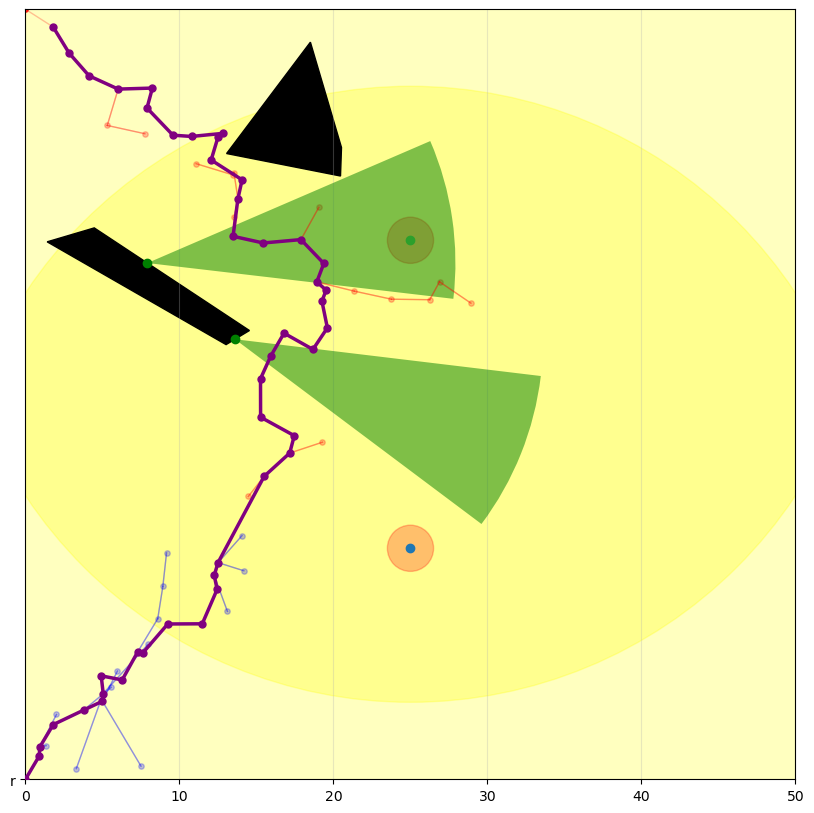

In [24]:
fig, ax = visualization(map_in, cam_dict, t=10, Va=Va, Vb=Vb, Ea=Ea, Eb=Eb, path_stp_rrt=computed_path)
plt.show()

In [25]:
# Export to json
stp_rrtstar_result = {}
stp_rrtstar_result['path'] = computed_path

# Vertex and Edge
stp_rrtstar_result['vertex'] = {}
stp_rrtstar_result['edge'] = {}
stp_rrtstar_result['vertex']['start_tree'] = Va
stp_rrtstar_result['edge']['start_tree'] = Ea
stp_rrtstar_result['vertex']['goal_tree'] = {}
stp_rrtstar_result['edge']['goal_tree'] = {}
for gti in range(n_partition):
    stp_rrtstar_result['vertex']['goal_tree'][str(gti)] = Vb[str(gti)]
    stp_rrtstar_result['edge']['goal_tree'][str(gti)] = Eb[str(gti)]
stp_rrtstar_result['computation_time'] = time_taken
stp_rrtstar_result['distance_cost'] = total_distance
stp_rrtstar_result['time_cost'] = total_time

# Save as json file
# file_path_stp_rrtstar = os.path.join("json", "stp_rrt_result.json")
file_path_stp_rrtstar = os.path.join("json/zero_sum_game", "stp_rrt_result.json")

with open(file_path_stp_rrtstar, "w") as f:
    json.dump(stp_rrtstar_result, f, indent=4)

Topology map

In [26]:
def angle_wrap_pi(a):
    """Wrap angle to (-pi, pi]. Works on numpy arrays."""
    return (a + np.pi) % (2*np.pi) - np.pi

def wedge_mask_grid(X, Y, sx, sy, facing_rad, fov_range, fov_half_rad):
    """
    Returns boolean mask of points (X,Y) that lie inside the directional sensor wedge.

    X, Y: meshgrid arrays of cell centers
    sx, sy: sensor position
    facing_rad: sensor facing angle in radians
    fov_range: max range
    fov_half_rad: half-angle (radians), so full FOV is 2*fov_half_rad
    """
    dx = X - sx
    dy = Y - sy
    R = np.hypot(dx, dy)

    bearing = np.arctan2(dy, dx)                     # angle from sensor to cell
    dtheta = angle_wrap_pi(bearing - facing_rad)     # signed difference to facing

    return (R <= fov_range) & (np.abs(dtheta) <= fov_half_rad), R

In [27]:
def detection_cost_directional_grid(
    X, Y,
    sx, sy,
    facing_rad,
    fov_range,
    fov_half_rad,
    dt1=0.0,
    dt2 = fov_rng,
    param_lambda=1.0,
    param_beta=0.25
):
    mask, R = wedge_mask_grid(X, Y, sx, sy, facing_rad, fov_range, fov_half_rad)

    Z = np.zeros_like(R, dtype=float)

    # Only compute inside the wedge; outside stays 0
    Rin = R[mask]

    # Apply your piecewise cost inside the wedge
    Zin = np.zeros_like(Rin, dtype=float)
    Zin[Rin <= dt1] = 1.0

    mid = (Rin > dt1) & (Rin < fov_range)  # dt2 = fov_range
    Zin[mid] = np.exp(-param_lambda * (Rin[mid] - dt1)**param_beta)

    # outside fov_range remains 0 already
    Z[mask] = Zin
    return Z, mask

In [28]:
def detection_cost_grid(X, Y, display_time):
    """
    Vectorized Elfes-like detection cost over a meshgrid (X, Y),
    for an omnidirectional sensor at (omni_sensor_pos_x, omni_sensor_pos_y).

    Returns:
        Z: same shape as X, detection cost in [0, 1]
    """
    # Setup
    Z = np.zeros((len(X), len(Y)))
    
    # Directional sensor
    Z_direc = np.zeros((len(X), len(Y)))
    # Camera parameters
    cx = np.array(cam_dict["x"], dtype=float)
    cy = np.array(cam_dict["y"], dtype=float)
    spec = cam_dict["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    # Facing angles at display_time
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], display_time)
        for i in range(len(cx))
    ], dtype=float)
    
    for i in range(len(cx)):
        sx, sy = cx[i], cy[i]
        facing = facings[i]          # radians
        fov_range = fov_range        # same as you used in Wedge
        fov_half = fov_half          # radians

        Z_direc_i, mask_i = detection_cost_directional_grid(
            X, Y,
            sx, sy,
            facing_rad=facing,
            fov_range=fov_range,
            fov_half_rad=fov_half,
            dt1=0.0,
            param_lambda=direc_param_lambda,
            param_beta=direc_param_beta
        )
        Z_direc += Z_direc_i
    Z_direc = Z_direc/len(cx)
    
    # Omnidirectional sensor
    Z_omni = np.zeros((len(X), len(Y)))
    for omni_i in range(num_omni):
        R_omni_i = np.sqrt((X - omni_sensor_pos_x[omni_i])**2 + (Y - omni_sensor_pos_y[omni_i])**2)
        Z_omni_i = np.zeros_like(R_omni_i, dtype=float)
        omni_dt1 = omni_sensor_range[omni_i]/dt1_denum
        omni_dt2 = omni_sensor_range[omni_i]

        # Region 1: fully detected
        Z_omni_i[R_omni_i <= omni_dt1] = 1.0
        mid = (R_omni_i > omni_dt1) & (R_omni_i < omni_dt2)

        raw = np.exp(-omni_param_lambda * (R_omni_i[mid] - omni_dt1)**omni_param_beta)
        raw_dt2 = np.exp(-omni_param_lambda * (omni_dt2 - omni_dt1)**omni_param_beta)

        # Normalize so Z(dt1)=1, Z(dt2)=0 continuously
        Z_omni_i[mid] = (raw - raw_dt2) / (1.0 - raw_dt2)
        Z_omni += Z_omni_i
    
    Z = Z_direc + Z_omni
    
    # Building locations should have cost of 1 (collision)
    for bi in range(map_in['st']['n']):
        building_coordinate = map_in["st"][str(bi)]
        pts = np.column_stack([X.ravel(), Y.ravel()])
        poly = Path(np.asarray(building_coordinate, dtype=float))
        inside = poly.contains_points(pts)  # boolean (Ny*Nx,)

        Mi = inside.reshape(X.shape).astype(np.uint8)
        for j in range(len(Mi)):
            for k in range(len(Mi[0])):
                if Mi[j][k] == 1:
                    Z[j][k] = 1
    return Z

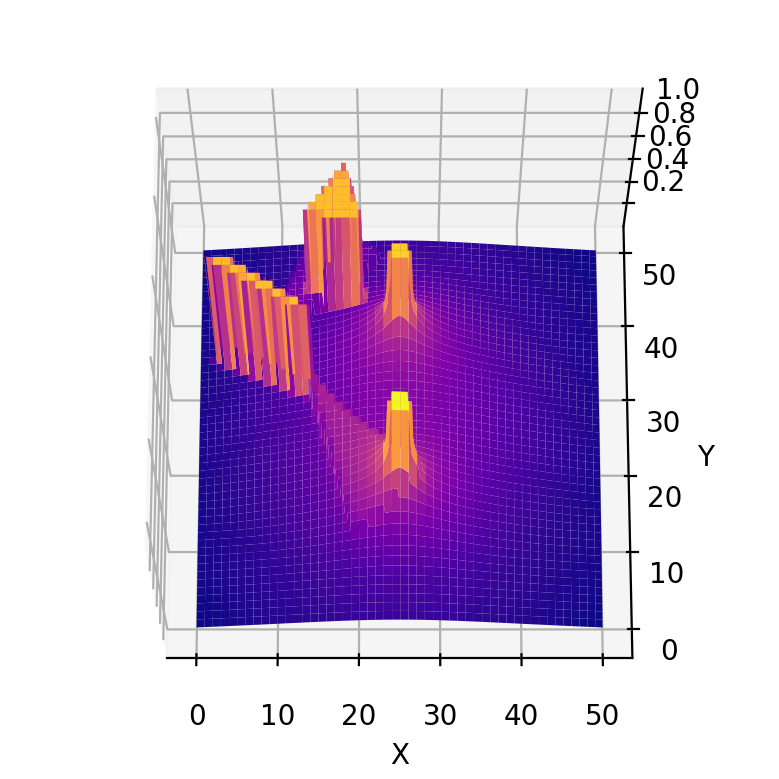

In [65]:
# %matplotlib widget

# Heatmap display at given time: display_time_t
display_time_t = 0
grid_N = 300
map_grid_x = np.linspace(int(map_in['st']['size'][0]), int(map_in['st']['size'][1]), grid_N)
map_grid_y = np.linspace(int(map_in['st']['size'][2]), int(map_in['st']['size'][3]),grid_N)
grid_X, grid_Y = np.meshgrid(map_grid_x, map_grid_y)

Z = detection_cost_grid(grid_X, grid_Y, display_time_t)

fig = plt.figure(dpi=200)
ax = fig.add_subplot(111, projection="3d")

# Change cmap for better visualization
# "viridis" (perceptually uniform, default)
# "inferno" / "plasma" (good contrast for heat)
# "terrain" (map-like)
# "coolwarm" (diverging around mid-value)

ax.plot_surface(grid_X, grid_Y, Z, cmap="plasma", linewidth=0)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.view_init(elev=70, azim=-90)
# ax.set_zlabel("Z (height)")

In [ ]:
import matplotlib.animation as animation

make_animation = False
if make_animation:
    # Set timescale for animation
    time_scale = 250
    t = np.linspace(0, computed_path[-1][2], time_scale)

    # Animation setup
    grid_N = 300
    map_grid_x = np.linspace(int(map_in['st']['size'][0]), int(map_in['st']['size'][1]), grid_N)
    map_grid_y = np.linspace(int(map_in['st']['size'][2]), int(map_in['st']['size'][3]),grid_N)
    grid_X, grid_Y = np.meshgrid(map_grid_x, map_grid_y)

    fig = plt.figure(dpi=200)
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    def update(frame):
        # for each frame, update the data stored on each artist.
        dt = t[frame]
        Z = detection_cost_grid(grid_X, grid_Y, dt)
        ax.plot_surface(grid_X, grid_Y, Z, cmap="plasma", linewidth=0)
        ax.view_init(elev=70, azim=frame%360)

    ani = animation.FuncAnimation(fig=fig, func=update, frames=time_scale, interval=20)
    ani.save(filename="image/stp_rrtstar/3D_heatmap_02.mp4", writer="ffmpeg")

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1280x960', '-pix_fmt', 'rgba', '-r', '50.0', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'image/stp_rrtstar/3D_heatmap_02.mp4']' returned non-zero exit status 255.